 **Task 3: Heart Disease Prediction**

 Intern: Muhammad Zoraiz Khan

 Organization: DevelopersHub Corporation

 Objective:  Predict heart disease risk using classification

Dataset Shape: (297, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


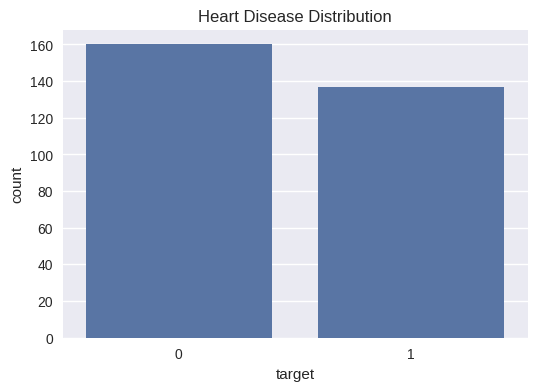

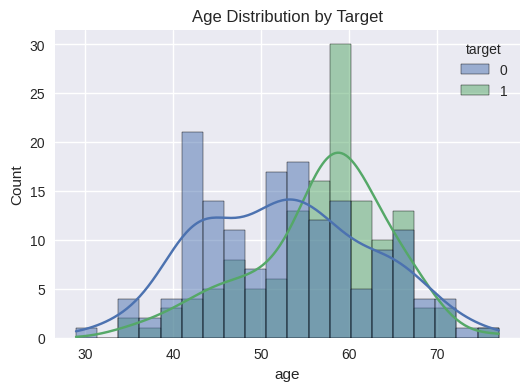

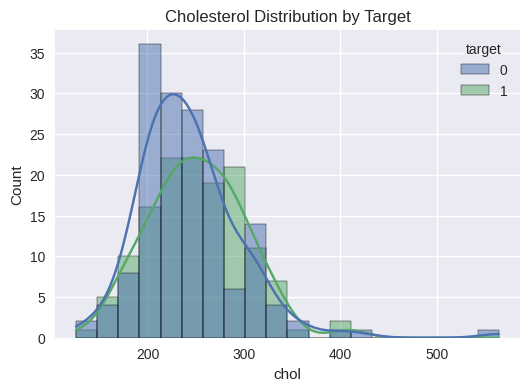

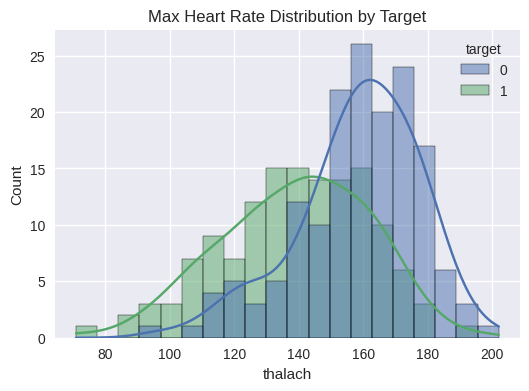

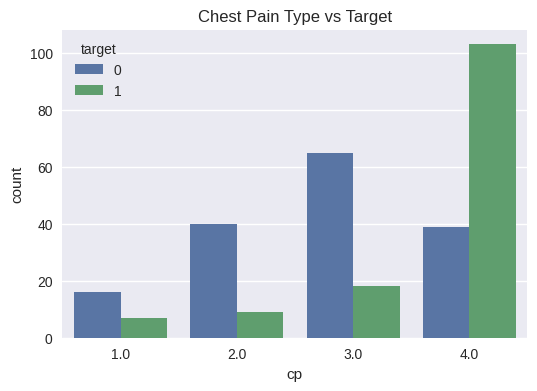

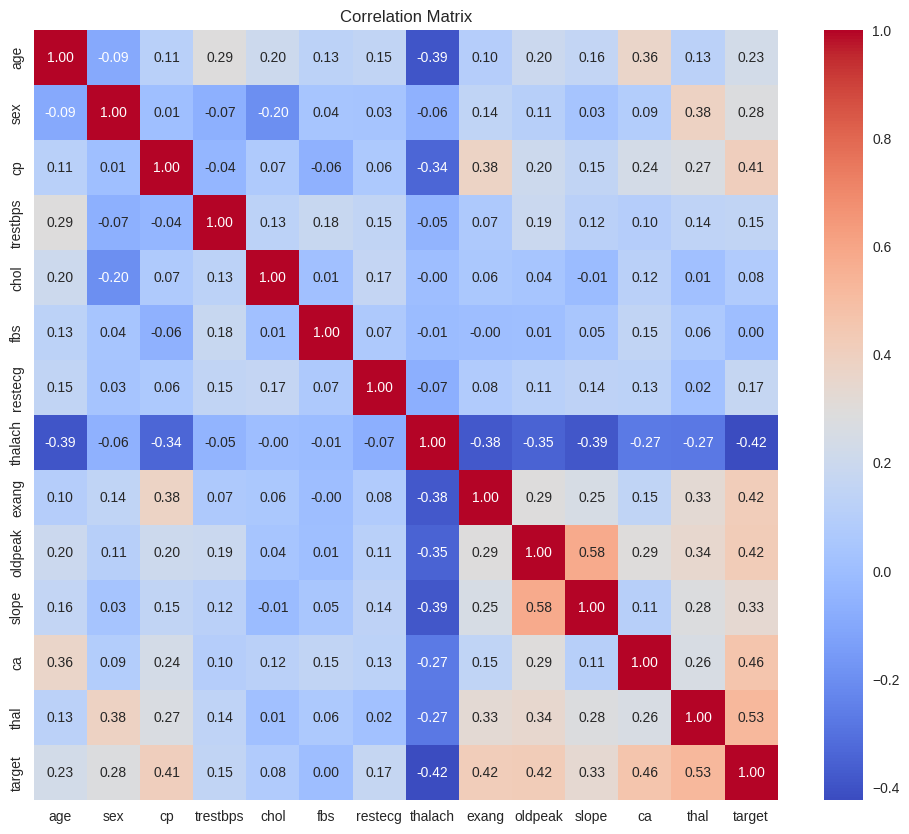

Accuracy: 0.8667
ROC AUC: 0.9421

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        36
           1       0.83      0.83      0.83        24

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



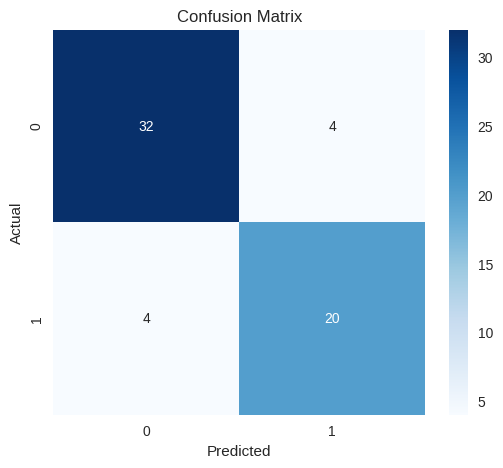

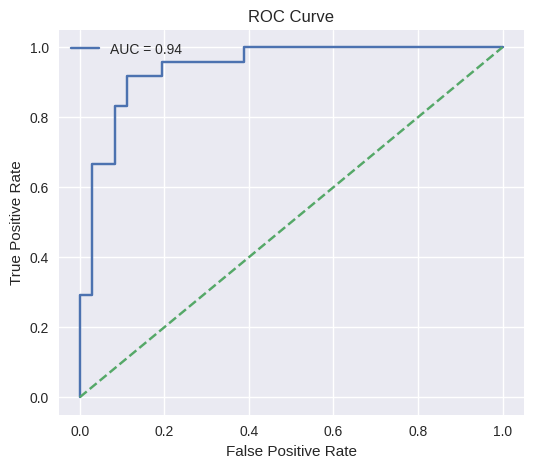

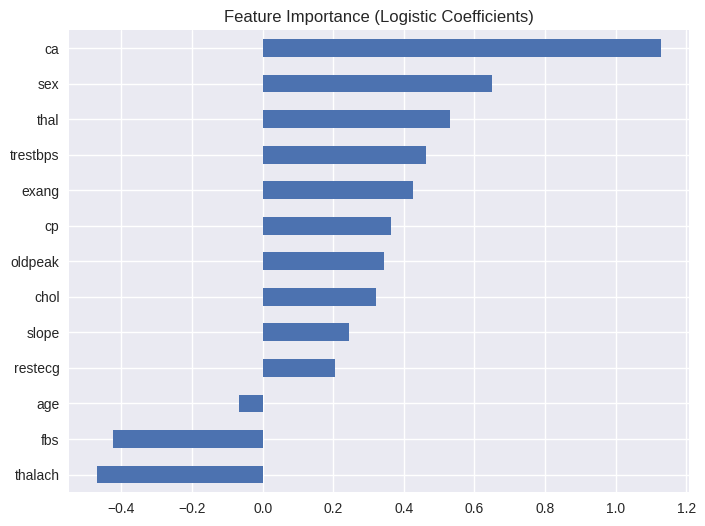

Feature Importance:
 thalach    -0.468190
fbs        -0.424769
age        -0.068079
restecg     0.205030
slope       0.243967
chol        0.320260
oldpeak     0.344207
cp          0.363644
exang       0.425264
trestbps    0.461525
thal        0.530384
sex         0.649002
ca          1.128567
dtype: float64

Manual Patient Tests
Patient 1: High Risk | Probability: 0.89
Patient 2: Low Risk | Probability: 0.0

Real Dataset Sample Check
Actual: Low Risk
Predicted: Low Risk


In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report

plt.style.use("seaborn-v0_8")
np.random.seed(42)

# Load UCI Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target"
]

df = pd.read_csv(url, names=columns)

# Data Cleaning
df.replace("?", np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

print("Dataset Shape:", df.shape)
print(df.head())

# -----------------------------
# Exploratory Data Analysis
# -----------------------------

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target")
plt.title("Heart Disease Distribution")
plt.show()

# Age vs Target
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", hue="target", bins=20, kde=True)
plt.title("Age Distribution by Target")
plt.show()

# Cholesterol vs Target
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="chol", hue="target", bins=20, kde=True)
plt.title("Cholesterol Distribution by Target")
plt.show()

# Max Heart Rate vs Target
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="thalach", hue="target", bins=20, kde=True)
plt.title("Max Heart Rate Distribution by Target")
plt.show()

# Chest Pain Type
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="cp", hue="target")
plt.title("Chest Pain Type vs Target")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# Model Training
# -----------------------------

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# -----------------------------
# Evaluation
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC AUC:", round(roc_auc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature Importance
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8,6))
coefficients.plot(kind="barh")
plt.title("Feature Importance (Logistic Coefficients)")
plt.show()

print("Feature Importance:\n", coefficients)

# -----------------------------
# Manual Test Cases
# -----------------------------

print("\nManual Patient Tests")

patients = pd.DataFrame([
    [65, 1, 3, 150, 260, 0, 1, 140, 1, 2.0, 2, 1, 3],  # High risk profile
    [42, 0, 1, 118, 180, 0, 0, 172, 0, 0.2, 1, 0, 2]   # Low risk profile
], columns=X.columns)

patients_scaled = scaler.transform(patients)

preds = model.predict(patients_scaled)
probs = model.predict_proba(patients_scaled)[:, 1]

for i in range(len(patients)):
    print(f"Patient {i+1}: {'High Risk' if preds[i]==1 else 'Low Risk'} | Probability: {round(probs[i],2)}")

# Real Sample Validation
sample = X_test[0:1]
actual = y_test.iloc[0]
predicted = model.predict(sample)[0]

print("\nReal Dataset Sample Check")
print("Actual:", "High Risk" if actual==1 else "Low Risk")
print("Predicted:", "High Risk" if predicted==1 else "Low Risk")

### Heart Disease Prediction Workflow

This code implements a complete workflow for predicting heart disease using a Logistic Regression model. Here's a breakdown of the steps:

*   **Load UCI Dataset**: The code begins by importing necessary libraries for data manipulation, visualization, and machine learning. It then loads the UCI Heart Disease dataset from a specified URL into a Pandas DataFrame, assigning meaningful column names.
*   **Data Cleaning**: It cleans the dataset by replacing '?' values with `np.nan` (missing values), converting all columns to a numeric type, and removing rows with any remaining missing values. The 'target' column, which indicates the presence of heart disease, is binarized (0 for no disease, 1 for disease).
*   **Exploratory Data Analysis (EDA)**: This section performs various visualizations to understand the data. It includes:
    *   **Target distribution**: A countplot to show the balance between patients with and without heart disease.
    *   **Age vs. Target**: A histogram to visualize age distribution segmented by heart disease status.
    *   **Cholesterol vs. Target**: A histogram to show cholesterol levels across heart disease groups.
    *   **Max Heart Rate vs. Target**: A histogram to display maximum heart rate distribution by target class.
    *   **Chest Pain Type**: A countplot to understand the distribution of different chest pain types relative to heart disease.
    *   **Correlation Heatmap**: A heatmap to illustrate the correlations between all features in the dataset, helping to identify relationships.
*   **Model Training**: The data is prepared for modeling by separating features (`X`) from the target variable (`y`). Features are scaled using `StandardScaler` to normalize their ranges, which is crucial for many machine learning algorithms. The scaled data is then split into training and testing sets. A `LogisticRegression` model is initialized and trained on the training data.
*   **Evaluation**: The trained model makes predictions on the test set, generating both class predictions (`y_pred`) and probability scores (`y_prob`). Model performance is assessed using accuracy score, ROC AUC score, and a detailed classification report. Visualizations include a confusion matrix to show correct and incorrect classifications, and an ROC curve to evaluate the classifier's performance across different threshold settings.
*   **Feature Importance**: The coefficients from the logistic regression model are used to determine and display the importance of each feature in predicting heart disease, showing which factors contribute most significantly to the model's decisions. This is visualized with a horizontal bar chart.
*   **Manual Test Cases**: Two custom patient profiles are created to manually test the model. For each patient, the model predicts whether they are 'High Risk' or 'Low Risk' for heart disease and provides the associated probability.
*   **Real Dataset Sample Check**: Finally, the model's prediction for a random sample from the test dataset is compared against its actual label, providing a quick sanity check of the model's real-world applicability.